In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras import optimizers
from keras.layers import LSTM
from keras.layers import Dense
from keras.models import Sequential
import math
processed_dpath = '/Users/oxide/Documents/research/orenstein/code/P288FinalProject/processed_data/'

In [61]:
##
## LSTM goal: predict erruption activity over the next predict_window minutes based
##            on erruption activity and other measurements over the last train_window minutes
##              
##            the input to this segment is dataInterpolated.csv, which has all the compiled data that we want to analysze
##

class LSTM_keras():

    def __init__(self, df, lstm_vars =['Eruption_Activity', 'VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM', 'VPRS_LFE',
       'VPRS_LFN', 'VPRS_LFZ', 'VPPC_LFE', 'VPPC_LFN', 'VPPC_LFZ', 'VPNC_LFE',
       'VPNC_LFN', 'VPNC_LFZ', 'CO2_ppm', 'lake_size']):
        """
        lstm_vars: what variables to actually use in the LSTM
        """

        # filter data to columns we want in LSTM and handle any nans
        df = df[lstm_vars]
        df.fillna(0, inplace=True)
        self.df = df # save DataFrame
        
        # preprocess data into numpy arrays
        self.df_scaled, self.scaler = NormAndScale(df)
        self.data = self.df_scaled.to_numpy()
        self.index = self.df.index

    def CreateModel(self, n_past=1, n_future=1, n_divide=80, n_neurons=800, n_epochs=150, learning_rate=0.001, momentum=0.4, opt ='adam'):
        
        print('Performing Training...')
        
        #calling normalized and scaled data
        data = self.data
        
        # reframe as learning problem
        X, Y = self.PrepareData(data, n_past, n_future)
        n_divide = round(len(data[:,0])*n_divide/100)
        train_X, train_Y = X[:n_divide], Y[:n_divide]
        test_X, test_Y = X[n_divide:], Y[n_divide:]

        # keep track of Datetime index across train/test set
        self.train_index = self.index[:n_divide]
        self.test_index = self.index[n_divide:]
 
        #design network: n_neurons stands for size of hidden layer
        model = Sequential()
        model.add(LSTM(n_neurons, input_shape=(train_X.shape[1], train_X.shape[2])))
        model.add(Dense(1))
        if opt == 'sgd':
            Opt = optimizers.SGD(learning_rate = learning_rate,\
                                 momentum = momentum)
        
        if opt == 'adam':
            Opt = optimizers.Adam(learning_rate = learning_rate)
        model.compile(loss = 'mae', optimizer = Opt)
        
        self.opt = opt
        self.momentum = momentum
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.n_past   = n_past
        self.n_future = n_future
        self.model    = model
        self.test_X   = test_X
        self.test_Y   = test_Y
        self.train_X  = train_X
        self.train_Y  = train_Y
        self.n_divide = n_divide

    def Fit(self):
        """
        fits the model
        """

        model = self.model
        n_epochs = self.n_epochs
        train_X = self.train_X
        train_Y = self.train_Y
        test_X = self.test_X
        test_Y = self.test_Y

        # fit network
        history = model.fit(train_X, train_Y, epochs = n_epochs, batch_size = 24*14,validation_data=(test_X, test_Y),verbose = 2, shuffle = False)

        #plot history
        plt.plot(history.history['loss'], label='train')
        plt.plot(history.history['val_loss'], label='test')
        plt.xlabel('epoch')
        plt.ylabel('loss [MSE]')
        plt.legend()
        plt.show()
        
        print('...Training Done!')

    def Predict(self):
        """
        predit Y on test set, unscale, store in a dataframe, and return the predicted dataframe
        """

        model = self.model
        X = self.test_X
        Yhat = model.predict(X)
        columns = self.df.columns
        df_scaled = pd.DataFrame(Yhat, columns=columns) # not sure yet how to handle index
        df = self.invNormAndScale(df_scaled)
        self.df_pred = df
        return df_pred

    def Forecast(self):
        """
        function that predicts on test_X and then plots. Below is just a sketch of what needs to happen.
        """
        
        Y    = self.df                  # this is just the orginal data
        Yhat_test  = self.Predict()     # this is the predicted data predicted from X_test

        # plot these two things together using PlotData to see how the prediction fared  

    ### Helper Functions ###

    def PlotData(self, dfs=None, log_vars=['Eruption_Activity', 'VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM']):
        """
        input list of dataframes to plot. This can be used to easily plot forecasts. They must have matching columns
        """

        if dfs is None:
            dfs = [self.df]
        if isinstance(dfs, pd.DataFrame):
            dfs = [dfs]
        columns = dfs[0].columns
        scale=3
        fig, ax = plt.subplots(math.ceil(len(columns)/2), 2, figsize=(8*scale, 0.75*scale*len(columns)), constrained_layout=True)
        ax = ax.flatten()

        for ds in dfs:
            for ii, c in enumerate(columns):
                df[c].plot(ax=ax[ii])
                ax[ii].set(ylabel=c, xlabel='Time')
                if c in log_vars:
                    ax[ii].set_yscale('log')

        fig.tight_layout(pad=10)
        plt.show()

    def PrepareData(self, data, n_past, n_future):
        """
        prepares timeseries data for regression (ie, makes coppies and stacks them). Data must already be a numpy array.
        """
        x, y = [], []
        for i in range(n_past, len(data) - n_future + 1):
            x.append(data[i - n_past:i])
            y.append(data[i:i + n_future])
        return np.array(x), np.array(y)
    
    def NormAndScale(self, dataframe):
        """
        return normalized dataframe and associated scalar transformation
        """
        
        # extracting values from dataframe
        df_scaled = dataframe.copy()
        data = df_scaled.to_numpy()
        
        # normalize
        scaler = MinMaxScaler(feature_range=(0, 1)) #normalize features
        scaled = scaler.fit_transform(data)
        
        # storing scaled values into a dataframe
        df_scaled[:] = scaled
            
        return df_scaled, scaler

    def invNormAndScale(self, dataframe, scaler):
        """
        given a normalized dataframe, undoes the normalization
        """

        # extracting values from dataframe
        df = dataframe.copy()
        data = df.to_numpy()
        
        # undo normaliztion
        unscaled = scaler.inverse_transform(data)

        # store unscaled values and return
        df[:] = unscaled

        return df

<>:138: SyntaxWarning: invalid escape sequence '\h'
<>:154: SyntaxWarning: invalid escape sequence '\h'
<>:138: SyntaxWarning: invalid escape sequence '\h'
<>:154: SyntaxWarning: invalid escape sequence '\h'
/var/folders/q_/x7kgmf911jj3y340hrv7mlp00000gn/T/ipykernel_48537/1836186609.py:138: SyntaxWarning: invalid escape sequence '\h'
  plt.legend(['$\hat{y}$','y'], loc = 'upper left')
/var/folders/q_/x7kgmf911jj3y340hrv7mlp00000gn/T/ipykernel_48537/1836186609.py:154: SyntaxWarning: invalid escape sequence '\h'
  plt.legend(['$\hat{y}$','y'], loc = 'upper left')


/var/folders/q_/x7kgmf911jj3y340hrv7mlp00000gn/T/ipykernel_48537/1836186609.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(0, inplace=True)


Performing Training...


/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2298/2298 - 52s - 23ms/step - loss: 0.2320 - val_loss: 0.2214


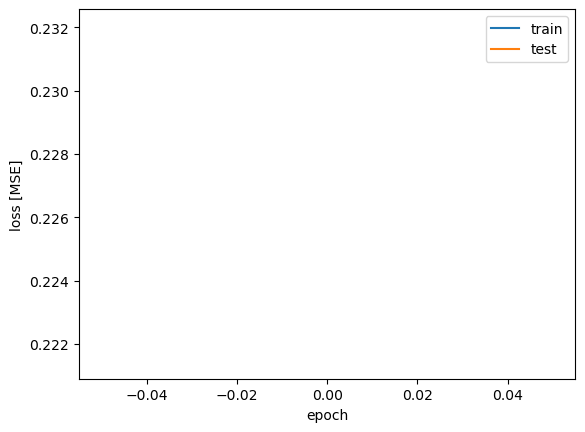

...Training Done!


In [63]:
# usage

# read in dataInterpolated.csv
df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)

# define variables for LSTM
lstm_vars = ['Eruption_Activity', 'VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM', 'VPRS_LFE',
       'VPRS_LFN', 'VPRS_LFZ', 'VPPC_LFE', 'VPPC_LFN', 'VPPC_LFZ', 'VPNC_LFE',
       'VPNC_LFN', 'VPNC_LFZ', 'CO2_ppm', 'lake_size'] 

lstm = LSTM_keras(df, lstm_vars=lstm_vars)
lstm.CreateModel(n_epochs=1)
lstm.Fit()

In [71]:
lstm.test_Y.shape

(192959, 1, 16)

In [68]:
lstm.test_X.shape

(192959, 1, 16)

In [66]:
model = lstm.model
X = lstm.test_X
Yhat = model.predict(X)
columns = lstm.df.columns
df_scaled = pd.DataFrame(Yhat, columns=columns) # not sure yet how to handle index
df = lstm.invNormAndScale(df_scaled)
lstm.df_pred = df

6030/6030 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


ValueError: Shape of passed values is (192959, 1), indices imply (192959, 16)